# LAB 3. STOCHASTIC GRADIENT DESCENT. SUBGRADIENT DESCENT

Let we have linear regression which takes the following form
$$y_i \approx f(x_i) = \omega_0 + \omega_1 x_i$$

We will use height as the input variable $x_i$ and weight as the output variable $y_i$ . The coefficients $\omega_0$ and $\omega_1$ are called model parameters. We will use a mean-square-error (MSE) function defined as
$$S(\omega_0, \omega_1) = \frac{1}{2n} \sum_{i=1}^{n} (y_i - f(x_i))^2 = \frac{1}{2n} \sum_{i=1}^{n} (y_i - \omega_0 - \omega_1 x_i)^2$$

We need to find $\omega_0$ and $\omega_0$ that minimize this cost function.
$$S(\boldsymbol{\omega}) = \frac{1}{2n} \lVert \mathbf{y} - \mathbf{X}\boldsymbol{\omega} \rVert^2$$
Recall from the Applied Linear Algebra that we can rewrite this problem in matrix form as
$$\mathbf{y} = \begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{pmatrix}, \mathbf{X} = \begin{pmatrix} 1 & x_1 \\ 1 & x_2 \\ \vdots & \vdots \\ 1 & x_n \end{pmatrix}, \boldsymbol{\omega} = \begin{pmatrix} \omega_0 \\ \omega_1 \end{pmatrix}$$

If we introduce the notation e=y-Xω, the MSE can also be rewritten as
$$S(\boldsymbol{\omega}) = \frac{1}{2n} \lVert \mathbf{e} \rVert^2$$

## 1. Solve MSE

Use your calculate_objective, compute_gradient and gradient_descent functions from Lab 1 (Assignment 2) and apply them with $\gamma = 1/\beta$ to solve MSE. In terms of our problem the update rule for gradient descent at step $k$ is$$\boldsymbol{\omega}^{k+1} = \boldsymbol{\omega}^k - \gamma \nabla S(\boldsymbol{\omega}^k).$$

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from prompt_toolkit.key_binding.bindings.named_commands import previous_history

In [2]:
df = pd.read_csv('weight-height.csv')

height = df['Height'].values
weight = df['Weight'].values

In [3]:
def calculate_objective(X, w, y):
    n = X.shape[0]
    return (1 / (2*n)) * np.sum((X@w - y)**2)

def compute_gradient(w, X, y):
    n = X.shape[0]
    return (1/n) * X.T@(X@w - y)

def gradient_descent(w_0, X, y, gamma, norm = 0.0001, iterations = 50):
    w = w_0
    results = []
    start_time = time.time()
    for iteration in range(iterations):
        f = calculate_objective(X, w, y)
        results.append(f)
        gradient = compute_gradient(w, X, y)
        if np.linalg.norm(gradient) < norm:
            break
        w = w-gamma*gradient

    running_time = time.time() - start_time

    return w, results, running_time

In [4]:
n = len(height)
X = np.column_stack((np.ones(n), height))
y = weight

beta = (1/n) * (np.linalg.norm(X, 2)**2)
gamma = 1/beta

w_0 = np.zeros(2)

w_gd, results_gd, running_time = gradient_descent(w_0, X, y, gamma)
print(f"Gamma = {gamma}\nRunning time = {running_time}\nResults = {w_gd}\n")


Gamma = 0.00022622122881210606
Running time = 0.006058931350708008
Results = [0.0235015  2.44986236]



## 2.  Implement stochastic gradient descent.

Recall from the lecture that the update rule for stochastic gradient descent on an objective function $S(\boldsymbol{\omega}) = \frac{1}{n} \sum_{i=1}^{n} S_i(\boldsymbol{\omega})$ is $$\boldsymbol{\omega}^{k+1} = \boldsymbol{\omega}^k - \gamma \nabla S_i(\boldsymbol{\omega}^k),$$

where $S_i(\boldsymbol{\omega}) = \frac{1}{2}(y_i - \omega_0 - \omega_1 x_i)^2$ та $i \in \{1, 2, \dots, n\}$

In [14]:
def stochastic_gradient_descent(w0, X, y, gamma, ebs = 0.00000001, iterations = 1000):
    w = w0
    n = X.shape[0]
    results = []
    start_time = time.time()
    for k in range(iterations):
        gamma_k = gamma/ np.sqrt(k+1)
        i = np.random.randint(0, n)
        w_0 = w[0]
        w_1 = w[1]
        x_i = X[i][1]
        y_i = y[i]

        gradient_S_i = (w_0 + w_1*x_i - y_i) * np.array([1, x_i])

        results.append(calculate_objective(X, w, y))
        w = w-gamma_k*gradient_S_i

        if len(results) > 1:
            loss_dif = np.abs(results[-1] - results[-2])
            if loss_dif < ebs:
                print(f"Loss = {loss_dif}\n Iteration = {k}")
                break

    running_time = time.time() - start_time
    return w, results, running_time

In [15]:
gamma = 0.0005
w_sgd, results_sgd, time_sgd = stochastic_gradient_descent(w_0, X, y, gamma)

print(f"Gamma = {gamma}\n")
print(f"Running time = {time_sgd}\n")
print(f"w_sgd = {w_sgd}\n")
#print(f"Results = {results_sgd}\n")

Gamma = 0.0005

Running time = 0.07080841064453125

w_sgd = [0.00607843 2.49382004]



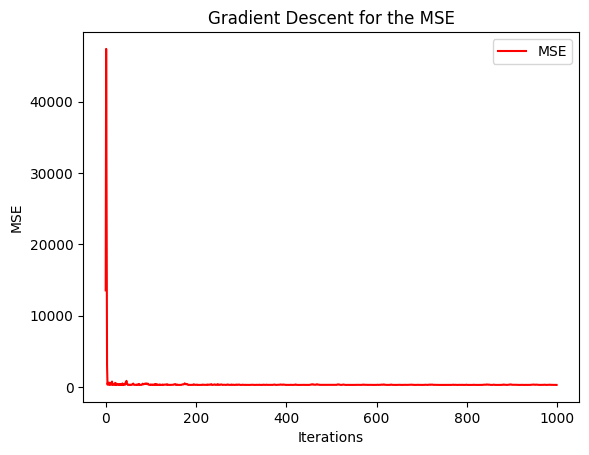

In [16]:
plt.figure()
plt.plot(results_sgd, color='red', label='MSE')
plt.title('Gradient Descent for the MSE')
plt.ylabel('MSE')
plt.xlabel('Iterations')
plt.legend()
plt.show()

## 3. Unfortunately, outliers might occur due to measurement errors

For example, in the weight/height data, a coding mistake could introduce points whose weight is measured in gram rather than kilograms. Such outlier points may have a strong influence on model parameters. For example, MSE is known to be sensitive to outliers.
One way to deal with outliers is to use a more robust cost function, such as the Mean Absolute Error (MAE):
$$A(\omega_0, \omega_1) = \frac{1}{n} \sum_{i=1}^{n} |y_i - f(x_i)| = \frac{1}{n} \sum_{i=1}^{n} |y_i - \omega_0 - \omega_1 x_i|,$$or in $e$-notation$$A(\omega_0, \omega_1) = \frac{1}{n} \sum_{i=1}^{n} |e_i|.$$


In [23]:
def calculate_objective_mae(X, w, y):
    n = X.shape[0]
    return (1 / n) * np.sum(np.abs(X@w - y))

def compute_subgradient_mae(X, w, y):
    n = X.shape[0]
    return (1/n) * X.T @ np.sign(X@w - y)

def subgradient_descent_mae(w_0, X, y, gamma, ebs = 0.00000001, iterations = 10000000):
    w = w_0
    results = []
    for k in range(iterations):
        gamma_k = gamma/ np.sqrt(k+1)
        results.append(calculate_objective_mae(X, w, y))
        subgradient = compute_subgradient_mae(X, w, y)
        w = w-gamma_k*subgradient
        if len(results) > 1:
            loss_dif = np.abs(results[-1] - results[-2])
            if loss_dif < ebs:
                print(f"Loss = {loss_dif}\n Iteration = {k}")
                break
    return w, results

Weight mae = [-7.99408541  2.5797128 ]



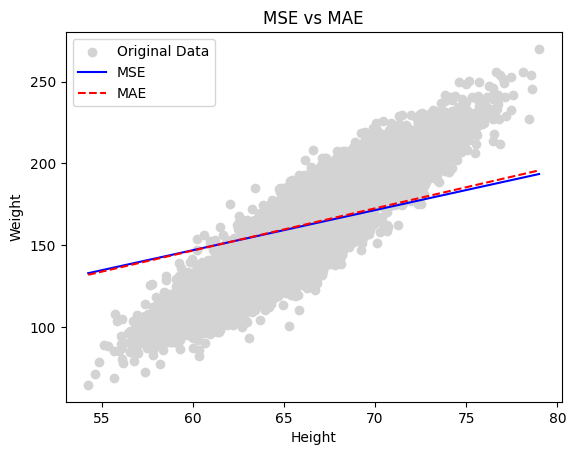

In [24]:
gamma = 0.03

w_mae, results_mae = subgradient_descent_mae(w_0, X, y, gamma)
x_values = np.linspace(height.min(), height.max())
y_mse = w_gd[0] + w_gd[1] * x_values
y_mae = w_mae[0] + w_mae[1] * x_values

print(f"Weight mae = {w_mae}\n")

plt.figure()
plt.scatter(height, y, color='lightgray',label='Original Data')
plt.plot(x_values, y_mse, color='blue', label='MSE')
plt.plot(x_values, y_mae, color='red', linestyle='--', label='MAE')
plt.title('MSE vs MAE')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend()
plt.show()

(a) Is the fit using MAE better than the one using MSE?
Трохи краще, якщо дивитися на результат, але там майже немає різниці. На графіку різницю майже неможливо помітити.

(b) Did your optimization algorithm ever encounter a non-differentiable point?
Ні, все через те як пайтон працює з float, функція наврядчи досягне 0. Бо функція np.sign() фактично ніколи не отримує на вхід чистий нуль і завжди знаходить похідну 1 або -1.

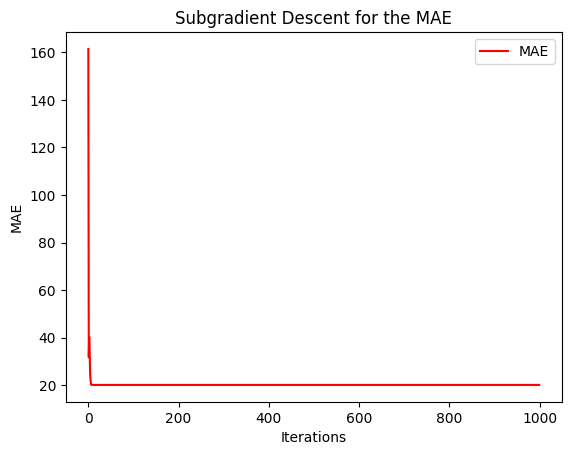

In [103]:
plt.figure()

plt.plot(results_mae, color='red', label='MAE')
plt.title('Subgradient Descent for the MAE')
plt.ylabel('MAE')
plt.xlabel('Iterations')
plt.legend()
plt.show()

## Implement stochastic subgradient descent for the MAE cost function.


In [104]:
def stochastic_subgradient_descent_mae(w0, X, y, gamma, ebs=0.0000001, iterations = 1000000):
    w = w0
    n = X.shape[0]
    results = []
    for k in range(iterations):
        gamma_k = gamma/ np.sqrt(k+1)
        i = np.random.randint(0, n)
        w_0 = w[0]
        w_1 = w[1]
        x_i = X[i][1]
        y_i = y[i]
        results.append(calculate_objective_mae(X, w, y))

        e_i = w_0 + w_1*x_i - y_i
        sign_i = np.sign(e_i)
        subgradient_i = sign_i * np.array([1, x_i])
        w = w-gamma_k*subgradient_i

        if len(results) > 1:
            loss_dif = np.abs(results[-1] - results[-2])
            if loss_dif < ebs:
                print(f"Loss = {loss_dif}\n Iteration = {k}")
                break

    return w, results

Gamma = 0.03

Weight mae = [-0.19671     2.57639629]



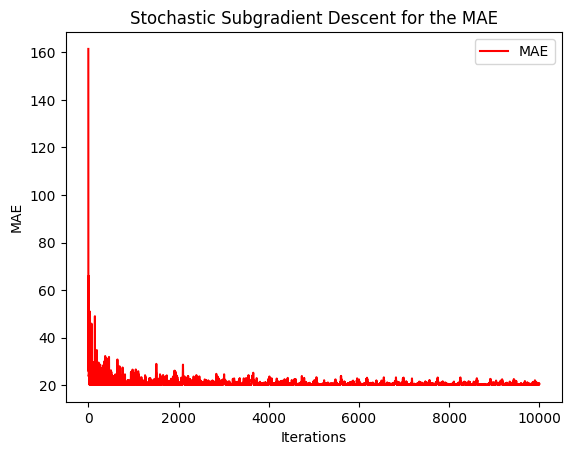

In [105]:
w_mae, results_stochastic_subgradient_descent_mae = stochastic_subgradient_descent_mae(w_0, X, y, gamma)

print(f"Gamma = {gamma}\n")
print(f"Weight mae = {w_mae}\n")

plt.figure()
plt.plot(results_stochastic_subgradient_descent_mae, color='red', label='MAE')
plt.title('Stochastic Subgradient Descent for the MAE')
plt.ylabel('MAE')
plt.xlabel('Iterations')
plt.legend()
plt.show()

How is the picture different when you compare the two algorithm variants on MAE, compared to what you have observed on MSE?




Theoretical questions 2 points
1. 0.5pts How can the steps in a subgradient descent algorithm be selected?

1) step length can be reduced either by choosing some a priori
sequence tending to 0

2) using the proximity of the function value at the current point to the minimum

3) Якщо відоме оптимальне значення функції, то крок обчислюється через відстань до нього

What steps did you use to complete this assignment? Why?

Я використовувала gamma/ np.sqrt(k+1)

2. 0.5pts Under what conditions do successive approximations in subgradient method converge to a solution to the unconditional minimization problem?

1) Функція повинна бути опуклою
2) Якщо функція сильно опукла з параметром $\mu > 0$ та має унікальний глобальний мінімум $x^*$


3. 0.5pts Under what conditions is the iterative process stopped in stochastic gradient descent?

Коли середнє значення функції починає покращуватись дуже маленькими кроками, або взагалі перестає покращуватись.

4. 0.5pts Can the subgradient descent method be used to minimize a differentiable function?

Так, можна, бо для диференційованих функцій субградієнт дорівнює градієнту => ми використовуємо звичайний градієнтний спуск.